# Implementing XGBoost in a Random Forest Classifier By Josh Meier

src: https://app.pluralsight.com/code-labs/contents/1f129fc1-39be-4f45-8ae8-bcd172ebfb74/learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

## Synthetic Data Generation

In [2]:
# Generate synthetic data
X, y = make_classification(n_samples=50000,
                           n_features=15,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training Both Models

In [3]:
### Train XGBoost Random Forest Classifier
xgb_rf = xgb.XGBRFClassifier(n_estimators=100,
                             max_depth=5,
                             learning_rate=0.2,
                             reg_lambda = 1,
                             reg_alpha = 0,
                             subsample=0.6,
                             colsample_bynode=0.6)
xgb_rf.fit(X_train, y_train)
y_pred_xgb = xgb_rf.predict(X_test)

In [4]:
### Train Standard Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## Evaluating Both Models

In [5]:
# Evaluate XGBoost Random Forest
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nXGBoost Random Forest Accuracy: {accuracy_xgb:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Evaluate Standard Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nStandard Random Forest Accuracy: {accuracy_rf:.4f}")
print("\nStandard RF Classification Report:")
print(classification_report(y_test, y_pred_rf))


XGBoost Random Forest Accuracy: 0.8631

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4911
           1       0.86      0.87      0.87      5089

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


Standard Random Forest Accuracy: 0.8603

Standard RF Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4911
           1       0.86      0.87      0.86      5089

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



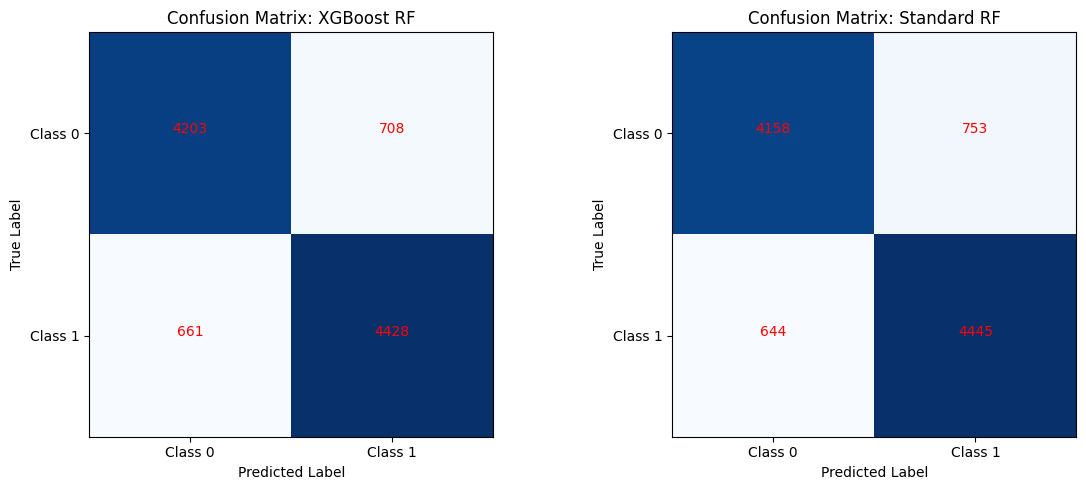

In [6]:
# Confusion Matrices
# Used for accuracy, and recall
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, matrix, title in zip(axes, [conf_matrix_xgb, conf_matrix_rf], ["XGBoost RF", "Standard RF"]):
    ax.imshow(matrix, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'Confusion Matrix: {title}')
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_yticklabels(['Class 0', 'Class 1'])
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    # Display values inside the matrix
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matrix[i, j]), horizontalalignment='center', color='red')

plt.tight_layout()
plt.show()